# Анализ и разработка решения для увеличения покупательской активности магазина «Победа качества»

## Импорт библиотек и файлов


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import requests

from io import StringIO
from math import ceil
from scipy.stats import shapiro

# ссылки на файлы с данными для задачи из моего репозитория
urls = {
    "market_file": "https://raw.githubusercontent.com/KirillovDmitrii/"
    "analysis_market_project/main/data/market_file.csv",
    "market_money": "https://raw.githubusercontent.com/KirillovDmitrii/"
    "analysis_market_project/main/data/market_money.csv",
    "market_time": "https://raw.githubusercontent.com/KirillovDmitrii/"
    "analysis_market_project/main/data/market_time.csv",
    "money": "https://raw.githubusercontent.com/KirillovDmitrii/"
    "analysis_market_project/main/data/money.csv",
    "forecast_chan": "https://raw.githubusercontent.com/KirillovDmitrii/"
    "analysis_market_project/main/data/forecast_chan.csv",
}


# чтение файла
def get_data(file_name, separ=",", dec="."):
    url = urls[file_name]
    try:
        df = pd.read_csv(url, sep=separ, decimal=dec)

    except:
        response = requests.get(url, verify=False)
        data = StringIO(response.text)
        df = pd.read_csv(data, sep=separ, decimal=dec)

    return df

#### Дополнительные функции для работы с файлами и данными


In [ ]:
# Функция для исправления кодировки текста (cp1251 -> utf-8)
def fix_text(text):
    if not isinstance(text, str):
        return text

    try:
        return text.encode("cp1251", errors="ignore").decode(
            "utf-8", errors="ignore"
        )
    except:
        return text


# преобразование данных в стандарт PEP8 и изменение кодировки данных
def fix_data(df):
    # правлю название столбцов
    df.columns = [fix_text(col) for col in df.columns]

    # правлю данные
    df = df.apply(lambda col: col.map(fix_text))
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    return df

## Чтение файлов

### Чтение файла market_file


In [ ]:
market_file_df = get_data("market_file")
market_file_df.head(3)

/Users/phoenix/PycharmProjects/IAL/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,id,РџРѕРєСѓРїР°С‚РµР»СЊСЃРєР°СЏ Р°РєС‚РёРІРЅРѕСЃС‚СЊ,РўРёРї СЃРµСЂРІРёСЃР°,Р Р°Р·СЂРµС€РёС‚СЊ СЃРѕРѕР±С‰Р°С‚СЊ,РњР°СЂРєРµС‚_Р°РєС‚РёРІ_6_РјРµСЃ,РњР°СЂРєРµС‚_Р°РєС‚РёРІ_С‚РµРє_РјРµСЃ,Р”Р»РёС‚РµР»СЊРЅРѕСЃС‚СЊ,РђРєС†РёРѕРЅРЅС‹Рµ_РїРѕРєСѓРїРєРё,РџРѕРїСѓР»СЏСЂРЅР°СЏ_РєР°С‚РµРіРѕСЂРёСЏ,РЎСЂРµРґРЅРёР№_РїСЂРѕСЃРјРѕС‚СЂ_РєР°С‚РµРіРѕСЂРёР№_Р·Р°_РІРёР·РёС‚,РќРµРѕРїР»Р°С‡РµРЅРЅС‹Рµ_РїСЂРѕРґСѓРєС‚С‹_С€С‚СѓРє_РєРІР°СЂС‚Р°Р»,РћС€РёР±РєР°_СЃРµСЂРІРёСЃР°,РЎС‚СЂР°РЅРёС†_Р·Р°_РІРёР·РёС‚
0,215348,РЎРЅРёР·РёР»Р°СЃСЊ,РїСЂРµРјРёСѓРј,РґР°,3.4,5,121,0.00,РўРѕРІР°СЂС‹ РґР»СЏ РґРµС‚РµР№,6,2,1,5
1,215349,РЎРЅРёР·РёР»Р°СЃСЊ,РїСЂРµРјРёСѓРј,РґР°,4.4,4,819,0.75,РўРѕРІР°СЂС‹ РґР»СЏ РґРµС‚РµР№,4,4,2,5
2,215350,РЎРЅРёР·РёР»Р°СЃСЊ,СЃС‚Р°РЅРґР°СЂС‚С‚,РЅРµС‚,4.9,3,539,0.14,Р”РѕРјР°С€РЅРёР№ С‚РµРєСЃС‚РёР»СЊ,5,2,1,5


Данные извлеклись нуждаются в обработке


In [4]:
market_file_df = fix_data(market_file_df)
market_file_df.head(3)

,id,покупательская_активность,тип_сервиса,_азрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5


Из-за ошибки кодировки столбец «*азрешить*сообщать» нужно переименовать в «разрешить_сообщать»


In [ ]:
market_file_df.rename(
    columns={"_азрешить_сообщать": "разрешить_сообщать"}, inplace=True
)
market_file_df.head(3)

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5


### Чтение файла market_money.csv


In [ ]:
market_money_df = get_data("market_money")
market_money_df.head(3)

/Users/phoenix/PycharmProjects/IAL/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,id,РџРµСЂРёРѕРґ,Р’С‹СЂСѓС‡РєР°
0,215348,РїСЂРµРїСЂРµРґС‹РґСѓС‰РёР№_РјРµСЃСЏС†,0.0
1,215348,С‚РµРєСѓС‰РёР№_РјРµСЃСЏС†,3293.1
2,215348,РїСЂРµРґС‹РґСѓС‰РёР№_РјРµСЃСЏС†,0.0


Файл market_money.csv нуждается в исправлении кодировки


In [ ]:
market_money_df = fix_data(market_money_df)
market_money_df.head(3)

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0


### Чтение файла market_time


In [ ]:
market_time_df = get_data("market_time")
market_time_df.head(3)

/Users/phoenix/PycharmProjects/IAL/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,id,РџРµСЂРёРѕРґ,РјРёРЅСѓС‚
0,215348,С‚РµРєСѓС‰РёР№_РјРµСЃСЏС†,14
1,215348,РїСЂРµРґС‹РґС†С‰РёР№_РјРµСЃСЏС†,13
2,215349,С‚РµРєСѓС‰РёР№_РјРµСЃСЏС†,10


Файл market_time.csv нуждается в исправлении кодировки


In [9]:
market_time_df = fix_data(market_time_df)
market_time_df.head(3)

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10


### Чтение файла money.csv


In [ ]:
money_df = get_data("money", separ=";", dec=",")
money_df.head(3)

/Users/phoenix/PycharmProjects/IAL/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,id,РџСЂРёР±С‹Р»СЊ
0,215348,0.98
1,215349,4.16
2,215350,3.13


Файл money.csv нуждается в исправлении кодировки


In [11]:
money_df = fix_data(money_df)
money_df.head(3)

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13


### Чтение файла forecast_chan.csv


In [ ]:
forecast_chan_df = get_data("forecast_chan", separ=";", dec=",")
forecast_chan_df.head(3)

/Users/phoenix/PycharmProjects/IAL/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,вероятность,id
0,1.00,215349
1,0.12,215350
2,0.97,215351


Файл forecast_chan прочитался правильно


## Предобработку данных

Предобработка данных включала: обработку пропусков, удаление дубликатов, работу с выбросами в числовых столбцах, проверку опечаток в категориальных столбцах и приведение типов данных


### Предобработка данных файла market_file.csv

#### Пропуски


In [13]:
market_file_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   str    
 2   тип_сервиса                          1300 non-null   str    
 3   разрешить_сообщать                   1300 non-null   str    
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   str    
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                       1300

Пустых ячеек нет

#### Дубликаты


In [14]:
market_file_df.duplicated().sum()

np.int64(0)

Дубликатов нет

#### Опечатки

Из условия такими колонками будут: Покупательская активность, Тип сервиса, Разрешить сообщать, Популярная_категория


In [ ]:
cat_col_market_file = [
    "покупательская_активность",
    "тип_сервиса",
    "разрешить_сообщать",
    "популярная_категория",
]
for col in cat_col_market_file:
    print(market_file_df[col].value_counts(), "\n")

покупательская_активность
Прежний уровень    802
Снизилась          498
Name: count, dtype: int64 

тип_сервиса
стандарт     914
премиум      376
стандартт     10
Name: count, dtype: int64 

разрешить_сообщать
да     962
нет    338
Name: count, dtype: int64 

популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксесуары                   223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: count, dtype: int64 



Есть опечатки в колонке тип_сервиса - стандартт


In [ ]:
market_file_df["тип_сервиса"] = market_file_df["тип_сервиса"].replace(
    "стандартт", "стандарт"
)
market_file_df["тип_сервиса"].value_counts()

тип_сервиса
стандарт    924
премиум     376
Name: count, dtype: int64

#### Изменение типа данных для категориальных столбцов


In [ ]:
market_file_df[cat_col_market_file] = market_file_df[
    cat_col_market_file
].astype("category")

#### Выбросы

Из условия числовые столбцы: 'маркет*актив_6*мес', 'маркет*актив*тек*мес', 'длительность', 'акционные*покупки', 'средний*просмотр*категорий*за*визит',
'неоплаченные*продукты*штук*квартал', 'ошибка*сервиса', 'страниц*за*визит'

Исследуем столбцы на возможность выбросов


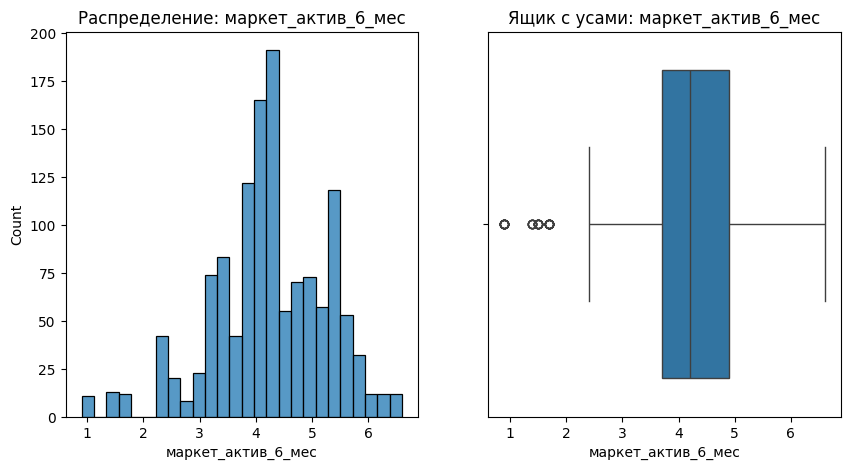

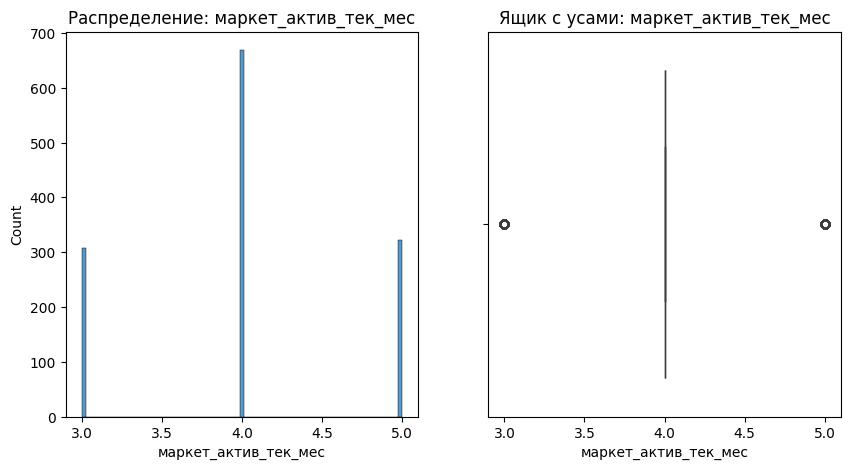

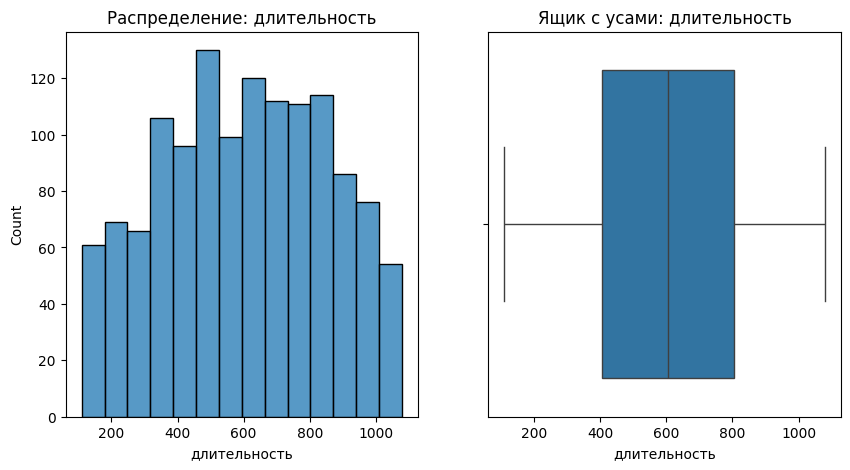

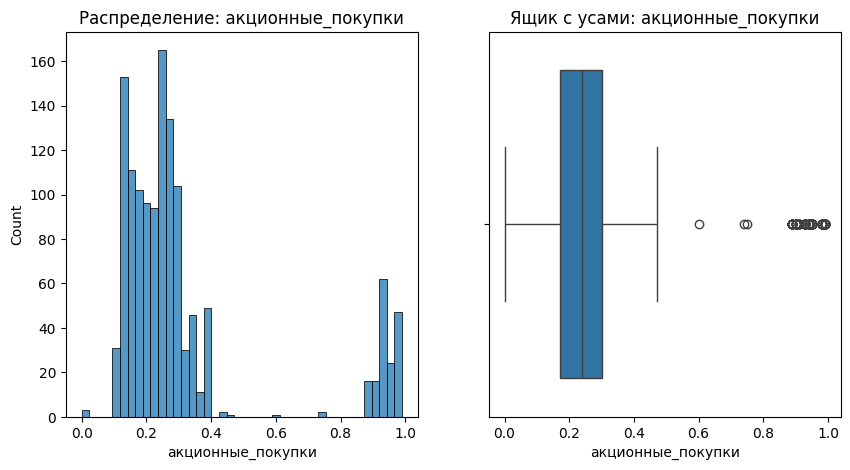

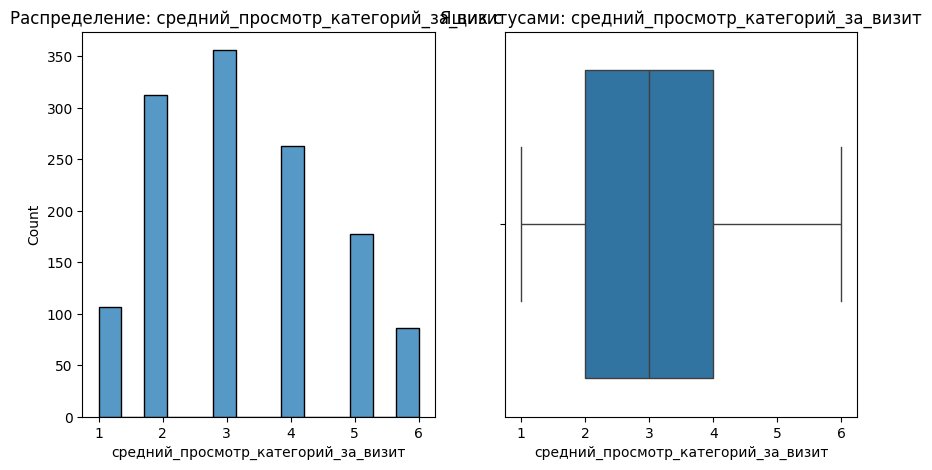

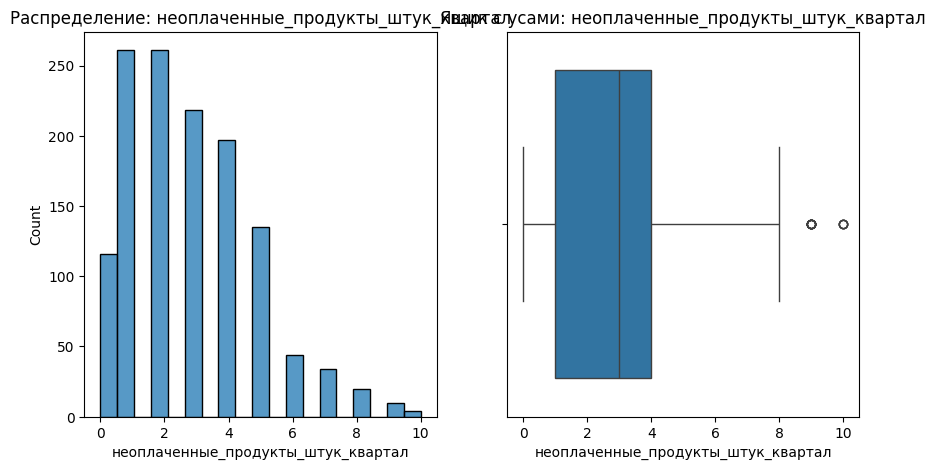

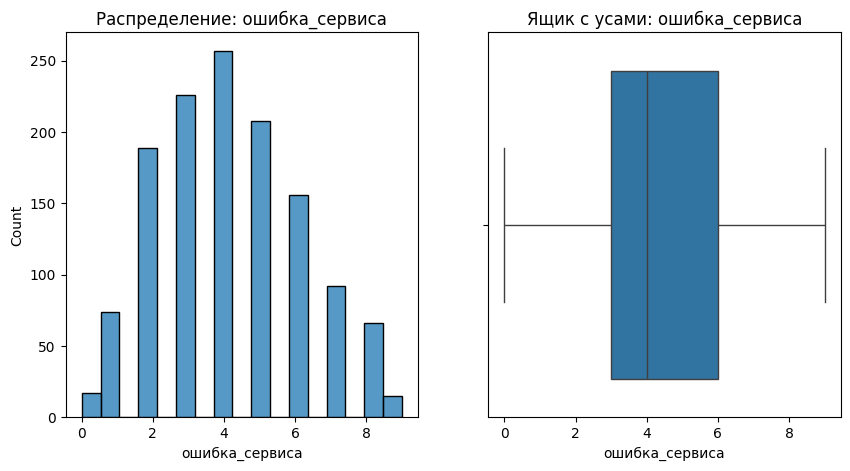

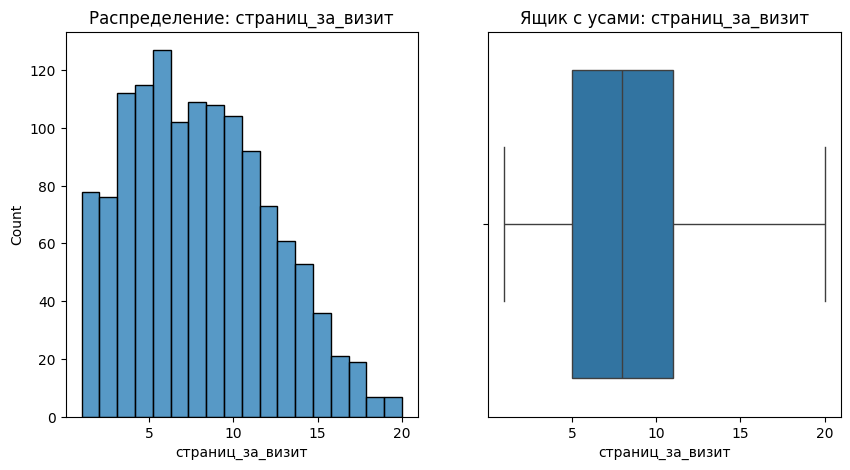

In [ ]:
num_col_market_file = [
    "маркет_актив_6_мес",
    "маркет_актив_тек_мес",
    "длительность",
    "акционные_покупки",
    "средний_просмотр_категорий_за_визит",
    "неоплаченные_продукты_штук_квартал",
    "ошибка_сервиса",
    "страниц_за_визит",
]

for i, col in enumerate(num_col_market_file):
    fig, axis = plt.subplots(1, 2, figsize=(10, 5))

    sns.histplot(market_file_df, x=col, ax=axis[0])
    axis[0].set_title(f"Распределение: {col}")

    sns.boxplot(market_file_df, x=col, ax=axis[1])
    axis[1].set_title(f"Ящик с усами: {col}")

    plt.show()

Дополнительный анализ столбцов, у которых наблюдаются выбросы: 'маркет*актив_6*мес', 'акционные*покупки', 'неоплаченные*продукты*штук*квартал'


In [ ]:
for col in [
    "маркет_актив_6_мес",
    "акционные_покупки",
    "неоплаченные_продукты_штук_квартал",
]:
    print(market_file_df[col].describe(), "\n")

count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64 

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64 

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64 



Дополнительный анализ числовых шкал показал, что значения "адекватные" (к примеру: нет отрицательных значений и т.д.). Выбросы не являются результатом ошибок данных, значит необходимо их оставить

#### Окончательный вид


In [20]:
market_file_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   id                                   1300 non-null   int64   
 1   покупательская_активность            1300 non-null   category
 2   тип_сервиса                          1300 non-null   category
 3   разрешить_сообщать                   1300 non-null   category
 4   маркет_актив_6_мес                   1300 non-null   float64 
 5   маркет_актив_тек_мес                 1300 non-null   int64   
 6   длительность                         1300 non-null   int64   
 7   акционные_покупки                    1300 non-null   float64 
 8   популярная_категория                 1300 non-null   category
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64   
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64   
 11  ошибка_сервиса              

### Предобработка данных market_money.csv

#### Пропуски


In [21]:
market_money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   str    
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 209.6 KB


Пропуски отсутствуют

#### Дубликаты


In [22]:
market_money_df.duplicated().sum()

np.int64(0)

Дубликатов нет

#### Опечатки

Для исследования подходит только одна категориальная шкала — период


In [ ]:
market_money_df["период"].value_counts()

период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

Опечаток нет

#### Изменение типа данных для категориальных столбцов


In [ ]:
market_money_df["период"] = market_money_df["период"].astype("category")

#### Выбросы

Исследуем колонку выручка


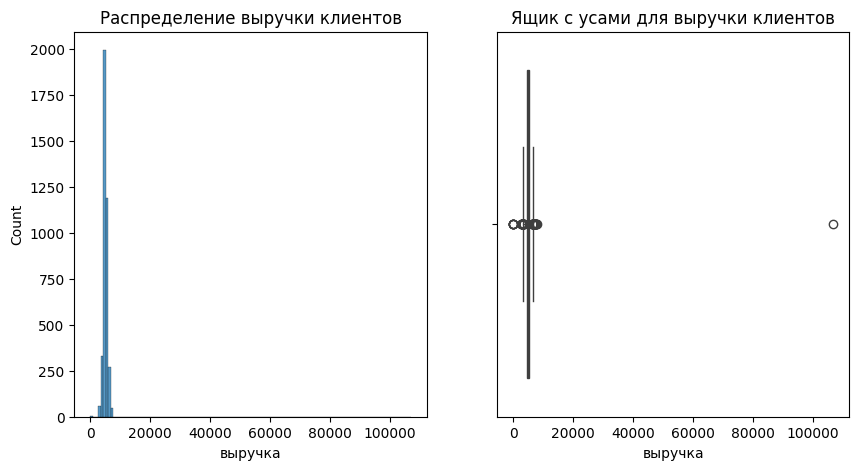

                  id        выручка
count    3900.000000    3900.000000
mean   215997.500000    5025.696051
std       375.325686    1777.704104
min    215348.000000       0.000000
25%    215672.750000    4590.150000
50%    215997.500000    4957.500000
75%    216322.250000    5363.000000
max    216647.000000  106862.200000


In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(market_money_df, x="выручка", ax=axis[0])
axis[0].set_title("Распределение выручки клиентов")

sns.boxplot(market_money_df, x="выручка", ax=axis[1])
axis[1].set_title("Ящик с усами для выручки клиентов")

plt.show()

print(market_money_df.describe())

По графику boxplot видно, что есть выброс. Даже если такой клиент действительно существовал, учитывать его в общем анализе нерелевантно, так как одно аномально большое значение может исказить результаты.

Также есть клиенты с нулевой выручкой. Это не ошибка, а группа клиентов, которые зарегистрировались, но пока ещё ничего не купили.

Изучим этого клиента, используя данные market_file


In [ ]:
# найдем id клиента с самой большой выручкой
id_mistake = market_money_df.loc[market_money_df["выручка"].idxmax(), "id"]

market_file_df[market_file_df["id"] == id_mistake]

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
32,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7


Данный клиент не создаёт новых выбросов по другим признакам (есть выше значение «акционные покупки»). Поэтому полностью удалять его нет смысла.

Необходимо определить, на какое значение заменить выброс: на среднее по всей выборке или на среднее по группе премиум-клиентов.


In [ ]:
# все id премиум клиентов
id_prem = market_file_df[
    (market_file_df["тип_сервиса"] == "премиум")
    & (market_file_df["id"] != id_mistake)
]["id"]
# все id обычных клиентов
id_med = market_file_df[market_file_df["тип_сервиса"] == "стандарт"]["id"]

# создадим группы по соответствующим пользователям (премиальных и обычных)
prem_group = market_money_df[market_money_df["id"].isin(id_prem)]
med_group = market_money_df[market_money_df["id"].isin(id_med)]

# среднее значение каждой группы
print(prem_group["выручка"].mean())
print(med_group["выручка"].mean())

5020.036355555556
4990.867063492064


Разница минимальна, но заменим выброс на среднее значение премиум группы


In [ ]:
market_money_df.loc[market_money_df["id"] == id_mistake, "выручка"] = (
    prem_group["выручка"].mean()
)

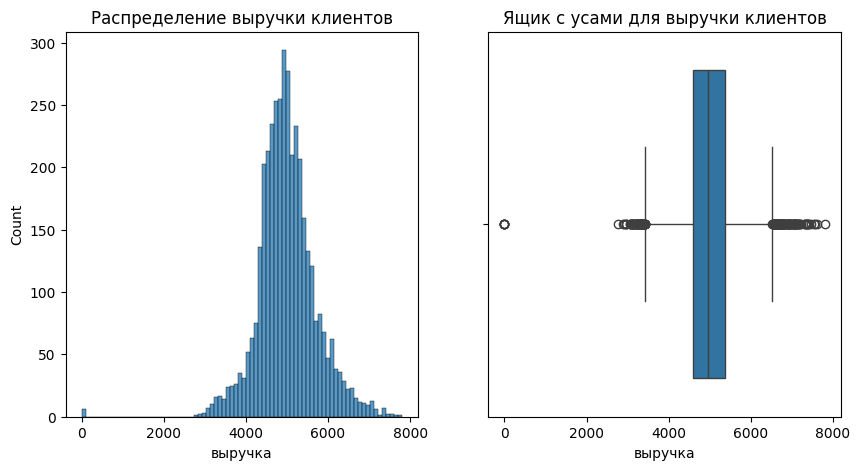

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(market_money_df, x="выручка", ax=axis[0])
axis[0].set_title("Распределение выручки клиентов")

sns.boxplot(market_money_df, x="выручка", ax=axis[1])
axis[1].set_title("Ящик с усами для выручки клиентов")

plt.show()

Значения файла market_money.csv без выбросов

#### Окончательный вид


In [30]:
market_money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   id       3900 non-null   int64   
 1   период   3900 non-null   category
 2   выручка  3900 non-null   float64 
dtypes: category(1), float64(1), int64(1)
memory usage: 65.0 KB


### Предобработка данных market_time.csv

#### Пропуски


In [31]:
market_time_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2600 non-null   int64
 1   период  2600 non-null   str  
 2   минут   2600 non-null   int64
dtypes: int64(2), str(1)
memory usage: 132.2 KB


Пропусков нет

#### Дубликаты


In [32]:
market_time_df.duplicated().sum()

np.int64(0)

Дубликатов нет

#### Опечатки


In [ ]:
market_time_df["период"].value_counts()

период
текущий_месяц       1300
предыдцщий_месяц    1300
Name: count, dtype: int64

Опечаток нет

#### Изменение типа данных для категориальных столбцов


In [ ]:
market_time_df["период"] = market_time_df["период"].astype("category")

#### Выбросы


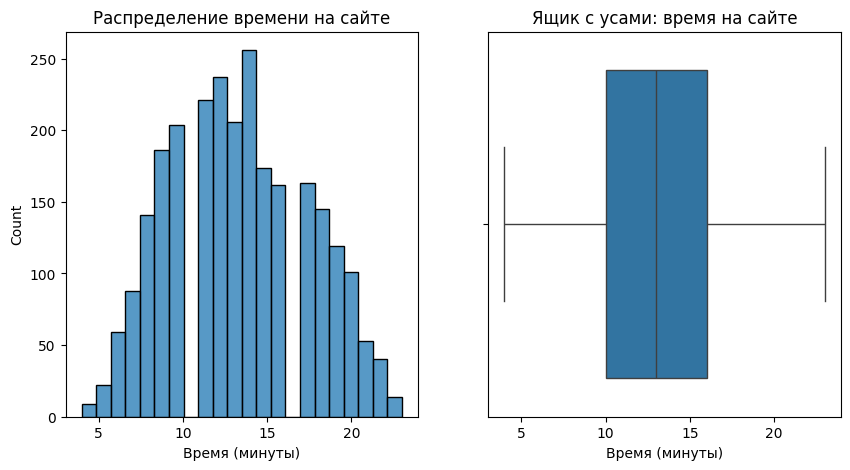

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(market_time_df, x="минут", ax=axis[0])
axis[0].set_title("Распределение времени на сайте")
axis[0].set_xlabel("Время (минуты)")

sns.boxplot(market_time_df, x="минут", ax=axis[1])
axis[1].set_title("Ящик с усами: время на сайте")
axis[1].set_xlabel("Время (минуты)")

plt.show()

Выбросов нет

#### Окончательный вид


In [36]:
market_time_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   id      2600 non-null   int64   
 1   период  2600 non-null   category
 2   минут   2600 non-null   int64   
dtypes: category(1), int64(2)
memory usage: 43.4 KB


### Предоработка данных money.csv

#### Пропуски


In [37]:
money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Пропусков нет

#### Дубликаты


In [38]:
money_df.duplicated().sum()

np.int64(0)

Дубликатов нет

#### Выбросы


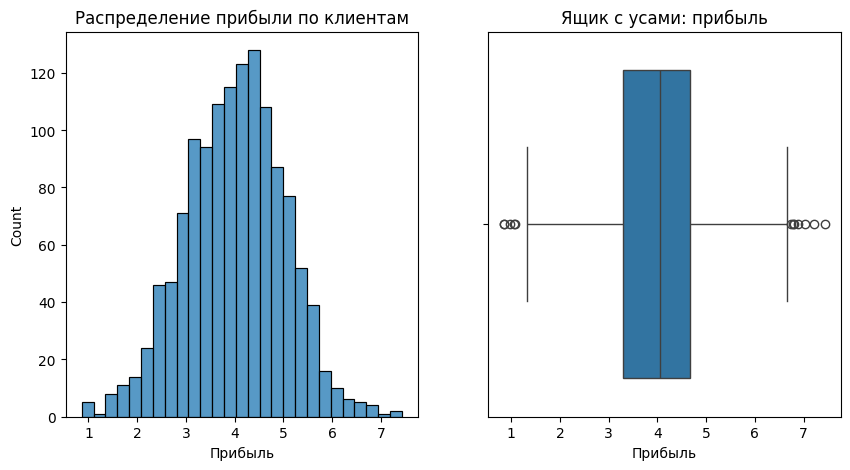

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(money_df, x="прибыль", ax=axis[0])
axis[0].set_title("Распределение прибыли по клиентам")
axis[0].set_xlabel("Прибыль")

sns.boxplot(money_df, x="прибыль", ax=axis[1])
axis[1].set_title("Ящик с усами: прибыль")
axis[1].set_xlabel("Прибыль")

plt.show()

Аномальных выбросов нет. Также это может дополнительно подтвердить, что выброс выручки в файле market_money.csv был, скорее всего, случайной ошибкой (иначе графики показали бы сильный выброс).

Категориальных столбцов нет, поэтому проверять опечатки не требуется. Все столбцы находятся в правильном формате.

#### Окончательный вид


In [40]:
money_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


### Предобработка данных forecast_chan.csv

#### Пропуски


In [41]:
forecast_chan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   вероятность  1297 non-null   float64
 1   id           1297 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


Пропусков нет

#### Дубликаты


In [42]:
forecast_chan_df.duplicated().sum()

np.int64(0)

Дубликатов нет

#### Исследуем на колонку вероятность


In [ ]:
forecast_chan_df["вероятность"].describe()

count    1297.000000
mean        0.374449
std         0.387556
min         0.000000
25%         0.120000
50%         0.120000
75%         0.900000
max         1.000000
Name: вероятность, dtype: float64

Значения вероятностей правильные для вероятностей (от 0 до 1)

Файл правильно оформлен

## Исследовательский анализ данных

### Анализ таблицы market_file


In [44]:
market_file_df.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


#### Покупательская активность


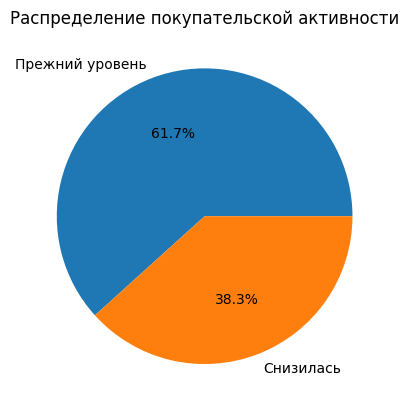

In [ ]:
pur_activity = market_file_df["покупательская_активность"]
counts = pur_activity.value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Распределение покупательской активности")
plt.show()

Видно, что у 61% клиентов покупательская активность снизилась (что подтверждает условие проблемы магазина)

#### Тип сервиса


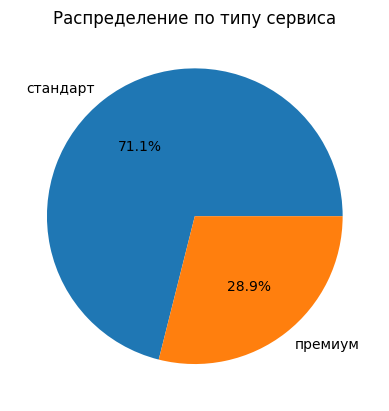

In [ ]:
service_type = market_file_df["тип_сервиса"]
counts = service_type.value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Распределение по типу сервиса")
plt.show()

29% клиентов являются премиум клиентами

#### Разрешить сообщать


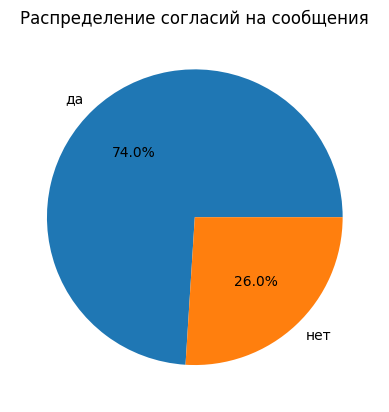

In [ ]:
notification = market_file_df["разрешить_сообщать"]
counts = notification.value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title("Распределение согласий на сообщения")
plt.show()

74% пользователей получают уведомления о дополнительных предложениях о товаре

#### Популярные категории


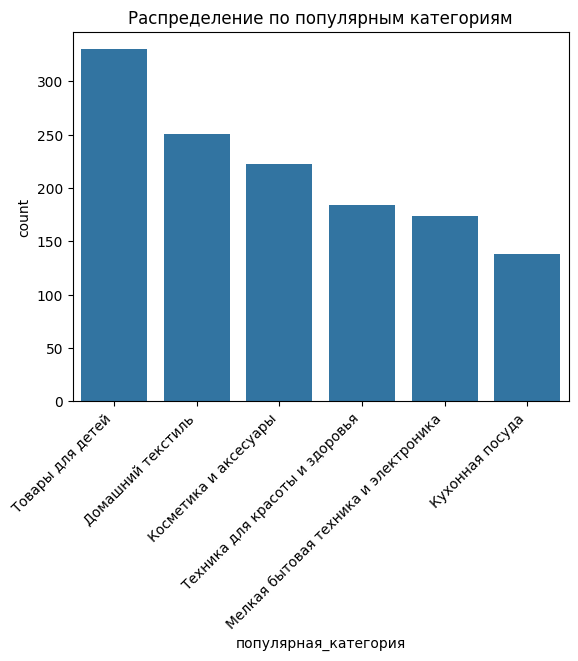

In [ ]:
sns.countplot(
    data=market_file_df,
    x="популярная_категория",
    order=market_file_df["популярная_категория"].value_counts().index,
)

plt.xticks(rotation=45, ha="right")
plt.title("Распределение по популярным категориям")
plt.show()

Больше всего продаж у категорий: "товары для детей", "домашний текстиль" и "косметика и аксесуеры"

#### Акционные покупки

Проанализировать долю акционных покупок у клиентов и выделить выбросы — клиентов с аномально высокой долей покупок по акции


Верхняя граница: 49.5%
Среднее значение: 31.98%


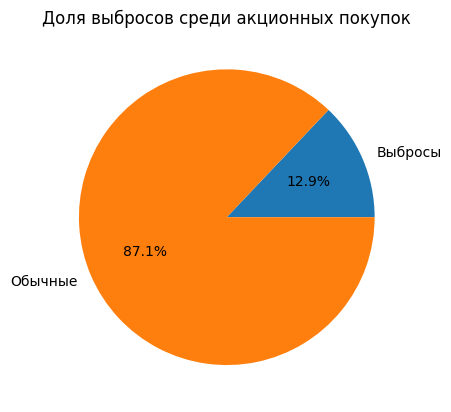

In [ ]:
discount = market_file_df["акционные_покупки"]

q1, q3 = discount.quantile([0.25, 0.75])
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

# клиенты с высокой долей покупок по акции
outliers = discount[discount > upper_bound]

# клиенты с нормальной долей покупок по акции
normal = discount[discount <= upper_bound]

print(f"Верхняя граница: {round(upper_bound * 100, 2)}%")
print(f"Среднее значение: {round(discount.mean() * 100, 2)}%")

plt.pie(
    [len(outliers), len(normal)],
    labels=["Выбросы", "Обычные"],
    autopct="%1.1f%%",
)
plt.title("Доля выбросов среди акционных покупок")
plt.show()

Круговая диаграмма показывает, что 13% клиентов имеют долю акционных покупок более 50%. При этом в среднем 32% всех покупок клиенты совершают по акции. Большинство клиентов (87%) покупают по акции менее половины своих товаров.

#### Длительность

Исследуем динамику поступления новых пользователей. Для удобства разобьём пользователей не по дням, а по полугодиям (183 дня).


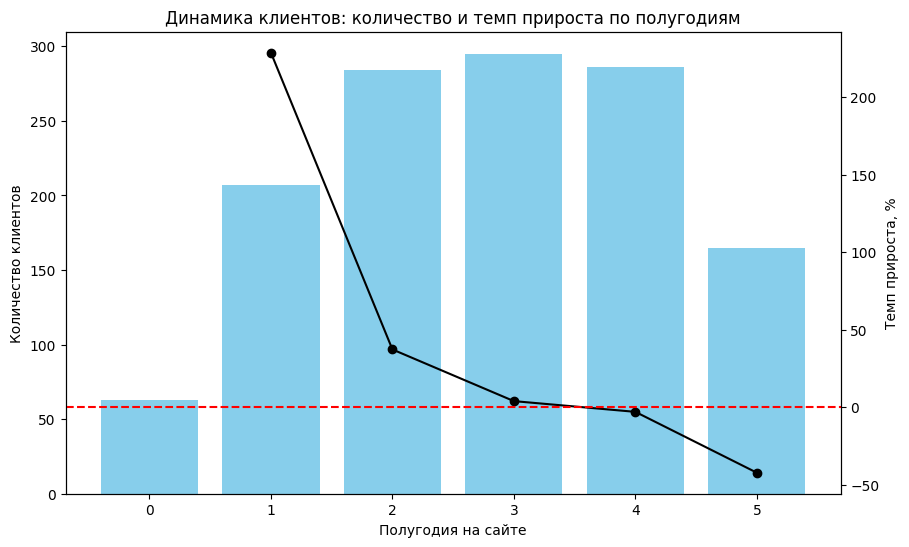

In [ ]:
# новый столбец, вычисляемый из длительности
market_file_df["полугодий_на_сайте"] = market_file_df["длительность"].apply(
    lambda x: ceil(x // 182)
)

# сортирую по полугодиям
dynamic = market_file_df["полугодий_на_сайте"].value_counts().sort_index()

# вычислю динамику между полугодиями
growth = dynamic.pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 6))

# гистограмма (количество клиентов) на первой оси
ax1.bar(
    dynamic.index, dynamic.values, color="skyblue", label="Количество клиентов"
)
ax1.set_xlabel("Полугодия на сайте")
ax1.set_ylabel("Количество клиентов")

# линия (темп прироста) на второй оси
ax2 = ax1.twinx()
ax2.plot(
    growth.index,
    growth.values,
    marker="o",
    color="black",
    label="Темп прироста, %",
)

# линия между отрицательным и положительным темпом роста
ax2.axhline(y=0, color="red", linestyle="--")
ax2.set_ylabel("Темп прироста, %")

plt.title("Динамика клиентов: количество и темп прироста по полугодиям")
plt.show()

Динамика по полугодиям действительно снижается (как писалось в задаче), но новые клиенты все еще поступают


#### Анализ количественных шкал

Диаграммы для числовых столбцов были сделаны ранее, дополню их описанием


In [51]:
market_file_df[num_col_market_file].describe()

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


1. маркет*актив_6*мес - видно, что для большинства клиентов приходится 4 маркетинговых коммуникаций, но есть небольшая группа, со значением меньше 2

2. маркет*актив*тек_мес - всего 3 значения (3, 4, 5) при этом большая часть клиентов получает 4 маркетинговых коммуникации. (это улучшает статистику группе, со среднем количеством менее 2 обращения за 6 месяцев)

3. средний*просмотр*категорий*за*визит - больше всего клиенты смотрят от 3 до 5 категорий.

4. неоплаченные*продукты*штук_квартал - в среднем 3 неоплаченных товара.

5. ошибка_сервиса - среднее число сбоев 4.

6. страниц*за*визит - среднее количество страниц за визит 8


### Анализ таблицы market_money

Колонка Период (исследовалась ранее в предобработке) имеет три категории:
препредыдущий*месяц 1300
текущий*месяц 1300
предыдущий_месяц 1300

#### Выручка


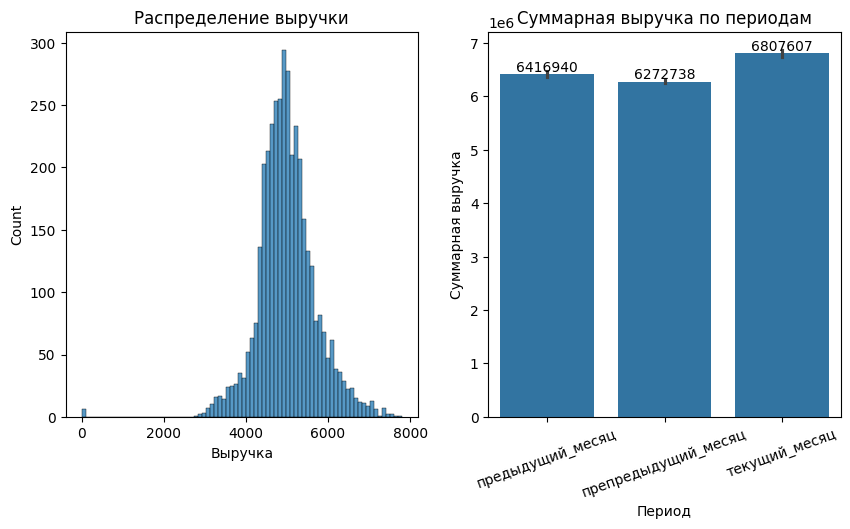

,id,выручка
count,3900.000000,3900.00000
mean,215997.500000,4999.30372
std,375.325686,706.69829
min,215348.000000,0.00000
25%,215672.750000,4590.15000
50%,215997.500000,4957.50000
75%,216322.250000,5362.62500
max,216647.000000,7799.40000


In [ ]:
# Визуализация распределения выручки и суммарной выручки по периодам
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(market_money_df, x="выручка", ax=axis[0])
axis[0].set_title("Распределение выручки")
axis[0].set_xlabel("Выручка")

sns.barplot(
    data=market_money_df, x="период", y="выручка", estimator="sum", ax=axis[1]
)
axis[1].set_title("Суммарная выручка по периодам")
axis[1].set_xlabel("Период")
axis[1].set_ylabel("Суммарная выручка")
axis[1].tick_params(axis="x", rotation=20)

for container in axis[1].containers:
    axis[1].bar_label(container, fmt="%.0f", fontsize=10)

plt.show()

# дополню описанием
market_money_df.describe()

среднее значение по выручке для всех клиентов примерно 5000, при этом есть клиенты. Также есть клиенты, которые еще не совершали покупок за определенный период.
выручка за каждый месяц примерно на одинаковом уровне, но за текущий месяц немного больше

### Анализ таблицы market_time

Колонка Период (исследовалась ранее в предобработке) имеет две категории:
предыдцщий*месяц 1300
текущий*месяц 1300

#### минут


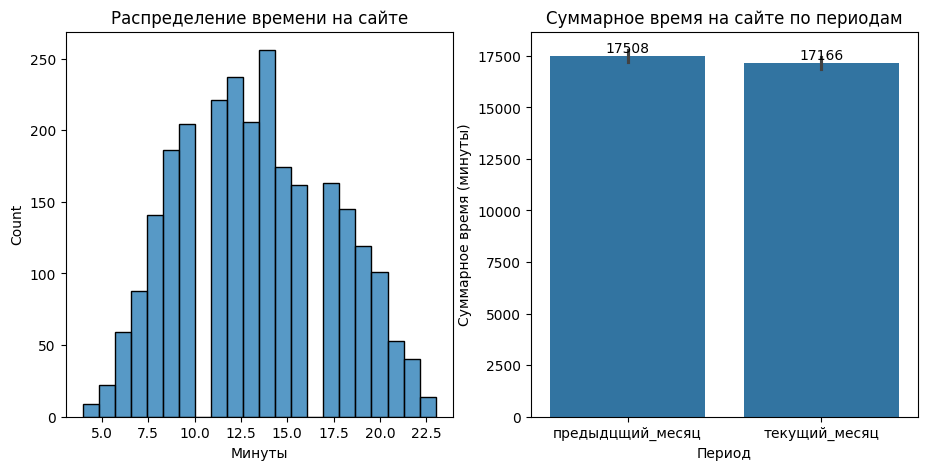

,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


In [ ]:
# Визуализация распределения минут и суммой минут по периодам
fig, axis = plt.subplots(1, 2, figsize=(11, 5))

sns.histplot(market_time_df, x="минут", ax=axis[0])
axis[0].set_title("Распределение времени на сайте")
axis[0].set_xlabel("Минуты")

sns.barplot(
    data=market_time_df, x="период", y="минут", estimator="sum", ax=axis[1]
)
axis[1].set_title("Суммарное время на сайте по периодам")
axis[1].set_xlabel("Период")
axis[1].set_ylabel("Суммарное время (минуты)")

for container in axis[1].containers:
    axis[1].bar_label(container, fmt="%.0f")

plt.show()

# дополню описанием столбцы минут
market_time_df.describe()

В среднем клиенты проводят на сайте 13 минут (75% пользователей проводят 16 минут) за период.  
Количество минут в текущем месяце немного снизилось ~300 минут

### Анализ таблицы money


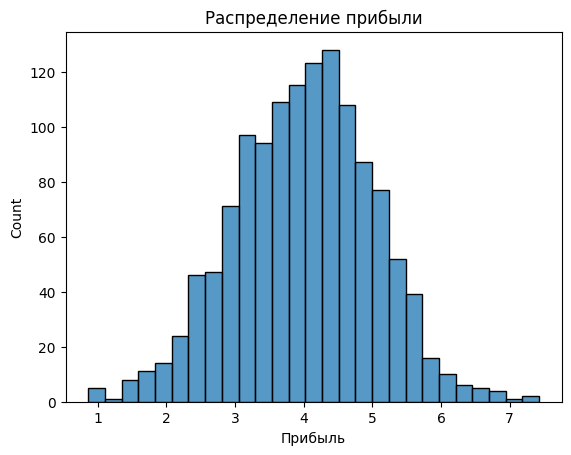

,id,прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


In [ ]:
sns.histplot(money_df, x="прибыль")
plt.title("Распределение прибыли")
plt.xlabel("Прибыль")
plt.show()

money_df.describe()

В среднем за 3 месяца магазин получает 4 прибыли с каждого клиента

### Анализ таблицы forecast_chan


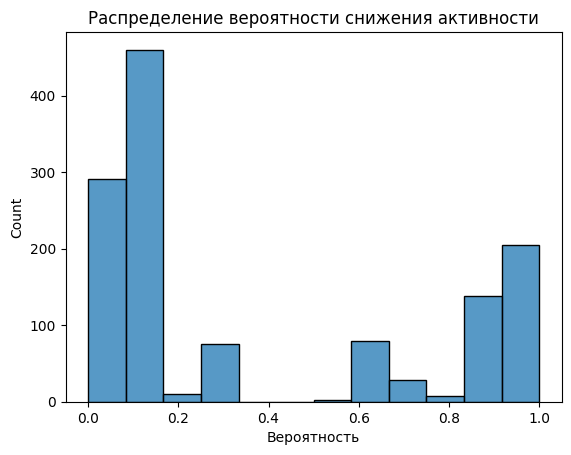

0    0.12
Name: вероятность, dtype: float64

In [ ]:
sns.histplot(forecast_chan_df, x="вероятность")
plt.title("Распределение вероятности снижения активности")
plt.xlabel("Вероятность")
plt.show()

forecast_chan_df["вероятность"].mode()

Больше всего клиентов имеют вероятность 12% снижения покупательской активности. Также видно большое количество клиентов, которые с высокой вероятностью (близко к 100%) покажу снижение активности (имеет смысл изучить таких клиентов подробнее, как отдельную группу и сравнить ее со "стабильной" группой)

### Отбор группы клиентов с покупательской активностью не менее трёх месяцев


In [ ]:
# Для каждого клиента вычисляется количество уникальных периодов,
# в которых была выручка > 0
active_months = (
    market_money_df[market_money_df["выручка"] > 0]
    .groupby("id")["период"]
    .nunique()
)

# id клиентов, для которых покупательская активность не менее трёх месяцев
id_active_clients = active_months[active_months >= 3].index

# дата фрейм с клиентами,
# у которых покупательская активность не менее трёх месяцев
active_client = market_file_df[market_file_df["id"].isin(id_active_clients)]
active_client.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,полугодий_на_сайте
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,2
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4


## Объединение таблиц market_file.csv, market_money.csv, market_time.csv


In [ ]:
# Делаю отдельный столбец для каждого периода.
money_pivot = market_money_df.pivot(
    index="id", columns="период", values="выручка"
).reset_index()
money_pivot.columns.name = None  # убираю имя у столбцов

# добавляю префикс 'выручка_', чтобы отличать столбцы
money_pivot.columns = ["id"] + [
    f"выручка_{col}" for col in money_pivot.columns[1:]
]

# Аналогично для времени на сайте
time_pivot = market_time_df.pivot(
    index="id", columns="период", values="минут"
).reset_index()
time_pivot.columns.name = None
time_pivot.columns = ["id"] + [
    f"время_{col}" for col in time_pivot.columns[1:]
]

# Объединение таблиц по id
merge_market_df = market_file_df.merge(money_pivot, on="id", how="left")
merge_market_df = merge_market_df.merge(time_pivot, on="id", how="left")

merge_market_df.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,полугодий_на_сайте,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,время_предыдцщий_месяц,время_текущий_месяц
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5,0,0.0,0.0,3293.1,13,14
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4,5216.0,4472.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,2,5457.5,4826.0,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4,6158.0,4793.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5,5807.5,4594.0,5872.5,8,11


## Корреляционный анализ

Необходимо провести корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования

Использую коэффициент корреляции Спирмена (более устойчив к выбросам и не требует нормального распределения данных)


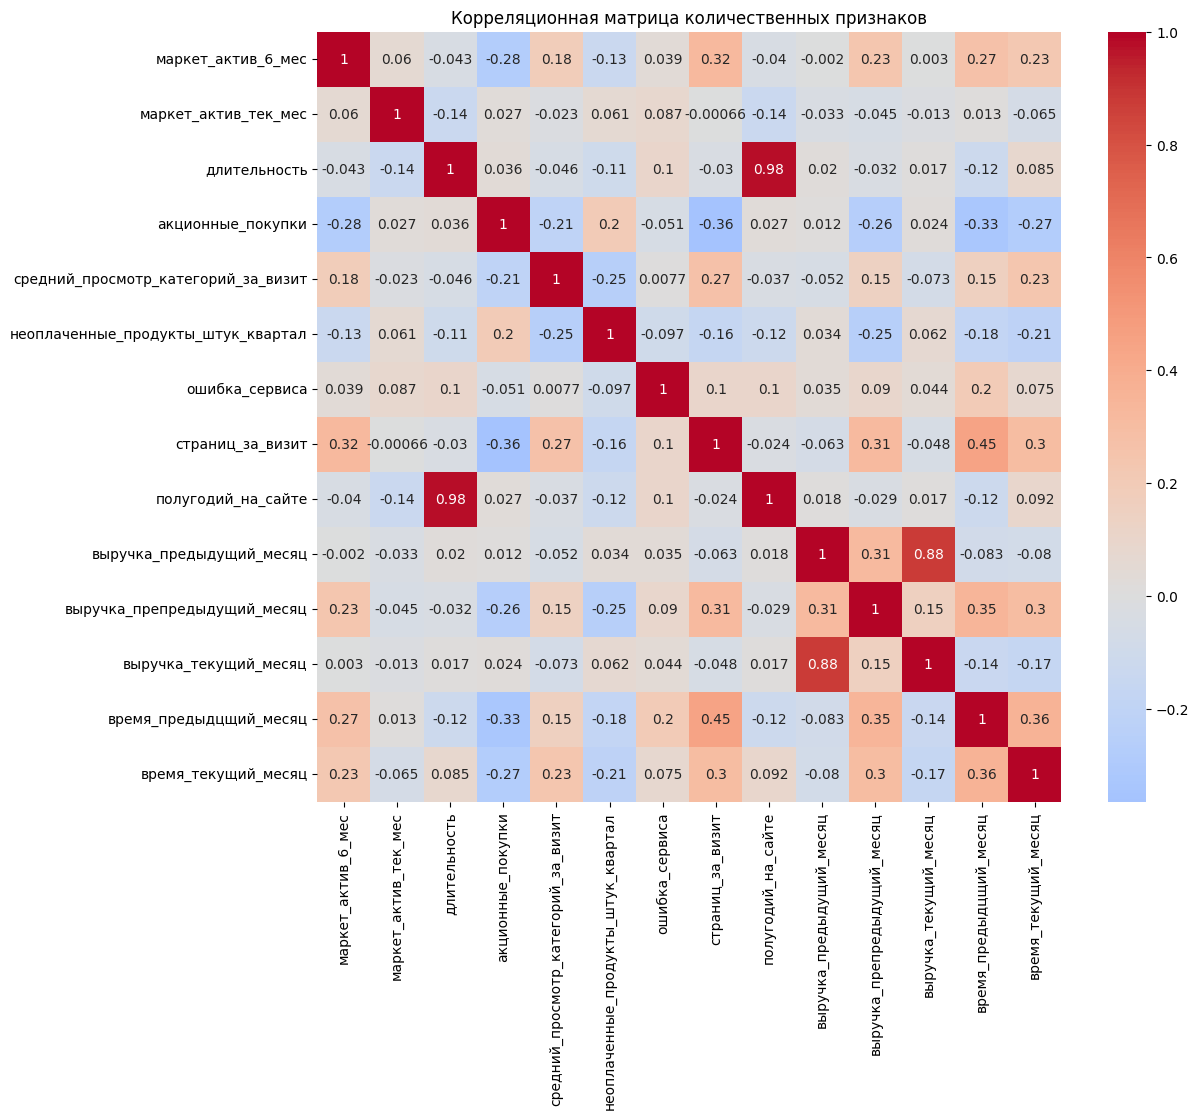

In [ ]:
# Выбираю только количественные шкалы
numeric_cols = merge_market_df.select_dtypes("number").columns
# Убираю колонку id
numeric_cols = [col for col in numeric_cols if col != "id"]

# Матрица корреляций между числовыми признаками
corr_matrix = merge_market_df[numeric_cols].corr(method="spearman")

# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица количественных признаков")
plt.show()

В ходе корреляционного анализа количественных признаков выявлена сильная положительная связь (мультиколлинеарность) между следующими парами:

длительность и полугодий*на*сайте (0.98).  
выручка*предыдущий*месяц и выручка*текущий*месяц (0.88).  
Остальные корреляции между признаками не превышают 0.5, что свидетельствует об отсутствии значимой мультиколлинеарности.  
В случае построения модели для устранения мультиколлинеарности:  
из пары длительность и полугодий*на*сайте оставляю длительность (как исходный признак).  
из пары выручка*предыдущий*месяц и выручка*текущий*месяц оставляю выручка*текущий*месяц (как более актуальный).

## Сегментация покупателей

Буду учитывать только тех покупателей, по которым есть данные модели


In [ ]:
# новый столбец, который вычисляется по вероятности снижения активности
forecast_chan_df["сегмент"] = pd.cut(
    forecast_chan_df["вероятность"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["низкий_риск", "средний_риск", "высокий_риск"],
)

# Добавляю столбец 'сегмент' к основной таблице
merge_market_df = merge_market_df.merge(
    forecast_chan_df[["id", "сегмент"]], on="id", how="inner"
)

merge_market_df.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,полугодий_на_сайте,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,время_предыдцщий_месяц,время_текущий_месяц,сегмент
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4,5216.0,4472.0,4971.6,12,10,высокий_риск
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,2,5457.5,4826.0,5058.4,8,13,низкий_риск
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4,6158.0,4793.0,6610.4,11,13,высокий_риск
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5,5807.5,4594.0,5872.5,8,11,высокий_риск
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4,4738.5,5124.0,5388.5,10,10,высокий_риск


Для анализа сегмента "Высокий риск" выбраны следующие факторы:

выручка*текущий*месяц — оценка ценности клиента.  
время*текущий*месяц — уровень вовлечённости.  
тип*сервиса — премиум или стандарт.  
покупательская*активность — текущий статус.  
акционные*покупки — чувствительность к акциям.  
разрешить*сообщать — возможность коммуникации.  
маркет*актив_6*мес — маркетинговая нагрузка.  
ошибка_сервиса — технические проблемы.

Также сравним сегменты «Высокий риск» и «Низкий риск» для выявления различий.


In [ ]:
interesting_col = [
    "выручка_текущий_месяц",
    "время_текущий_месяц",
    "тип_сервиса",
    "покупательская_активность",
    "акционные_покупки",
    "разрешить_сообщать",
    "маркет_актив_6_мес",
    "ошибка_сервиса",
]

# группы по вероятности снижения активности
low_risk = merge_market_df[merge_market_df["сегмент"] == "низкий_риск"][
    interesting_col
]

aver_risk = merge_market_df[merge_market_df["сегмент"] == "средний_риск"][
    interesting_col
]

hight_risk = merge_market_df[merge_market_df["сегмент"] == "высокий_риск"][
    interesting_col
]

print(f"Низкий риск: {len(low_risk)} клиентов")
print(f"Средний риск: {len(aver_risk)} клиентов")
print(f"Высокий риск: {len(hight_risk)} клиентов")

Низкий риск: 705 клиентов
Средний риск: 82 клиентов
Высокий риск: 378 клиентов


Достаточно большая доля клиентов (~30%) находится в зоне высокого риска снижения покупательской активности. Данный сегмент требует детального исследования для разработки мер по удержанию.

### выручка*текущий*месяц


Низкий риск - Среднее: 5169.97, Медиана: 5111.50
Высокий риск - Среднее: 5344.54, Медиана: 5316.50


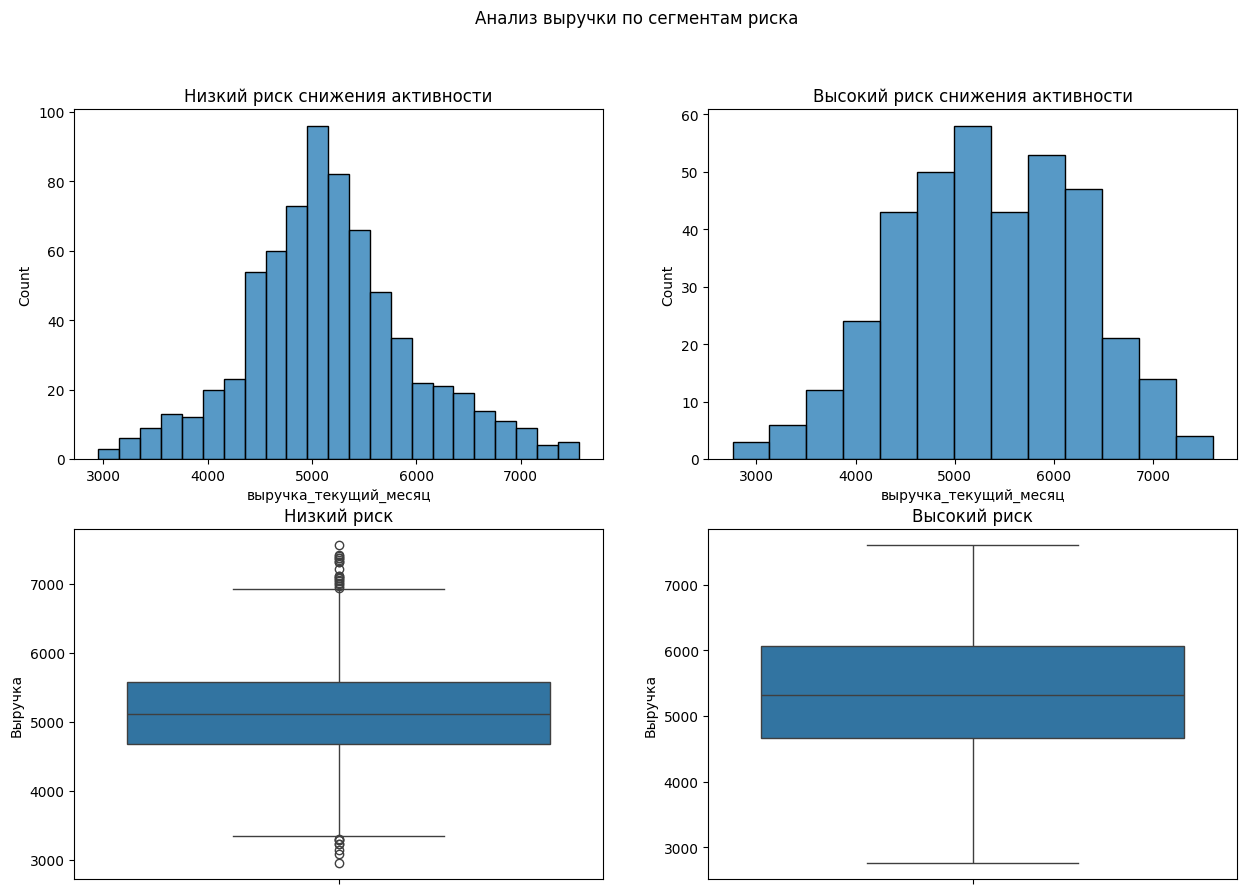

In [ ]:
print(
    f"Низкий риск - Среднее: {low_risk['выручка_текущий_месяц'].mean():.2f}, "
    f"Медиана: {low_risk['выручка_текущий_месяц'].median():.2f}"
)

print(
    f"Высокий риск - Среднее: {hight_risk['выручка_текущий_месяц'].mean():.2f},"
    f" Медиана: {hight_risk['выручка_текущий_месяц'].median():.2f}"
)

fig, axis = plt.subplots(2, 2, figsize=(15, 10))

# Верхний ряд - гистограммы
sns.histplot(low_risk, x="выручка_текущий_месяц", ax=axis[0, 0])
axis[0, 0].set_title("Низкий риск снижения активности")

sns.histplot(hight_risk, x="выручка_текущий_месяц", ax=axis[0, 1])
axis[0, 1].set_title("Высокий риск снижения активности")

# Нижний ряд - ящики с усами
sns.boxplot(y=low_risk["выручка_текущий_месяц"], ax=axis[1, 0])
axis[1, 0].set_title("Низкий риск")
axis[1, 0].set_ylabel("Выручка")

sns.boxplot(y=hight_risk["выручка_текущий_месяц"], ax=axis[1, 1])
axis[1, 1].set_title("Высокий риск")
axis[1, 1].set_ylabel("Выручка")

plt.suptitle("Анализ выручки по сегментам риска")
plt.show()

Для оценки различий между сегментами буду использовать медиану, так как она более устойчива к выбросам и не сильно отличается от среднего.

Ключевое наблюдение: Сегмент с высоким риском снижения активности демонстрирует наибольшую выручку по сравнению с другими сегментами (медиана выручки составляет 5316.50 руб. против 5111.50 руб. в сегменте низкого риска).

Возможно, высокая выручка в текущем периоде связана с крупными затратами, после которых в следующем месяце клиент экономит или у него отпадает необходимость в новых покупках. Это может объяснять прогнозируемое моделью снижение активности.

### время*текущий*месяц


Низкий риск - Среднее: 15.81 Медиана: 16.00
Высокий риск - Среднее: 10.40 Медиана: 10.00


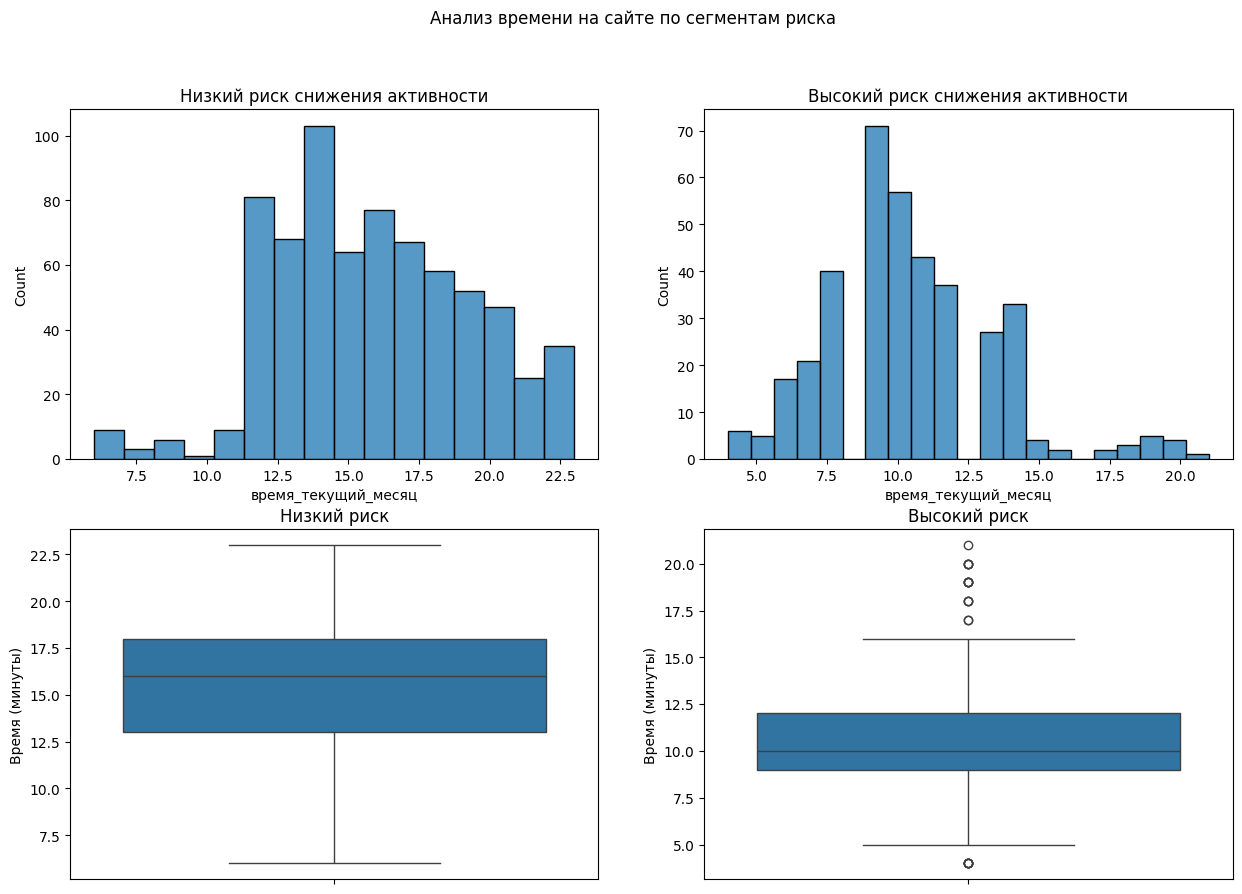

In [ ]:
print(
    f"Низкий риск - Среднее: {low_risk['время_текущий_месяц'].mean():.2f}",
    f"Медиана: {low_risk['время_текущий_месяц'].median():.2f}",
)
print(
    f"Высокий риск - Среднее: {hight_risk['время_текущий_месяц'].mean():.2f}",
    f"Медиана: {hight_risk['время_текущий_месяц'].median():.2f}",
)

fig, axis = plt.subplots(2, 2, figsize=(15, 10))

# Верхний ряд - гистограммы
sns.histplot(low_risk, x="время_текущий_месяц", ax=axis[0, 0])
axis[0, 0].set_title("Низкий риск снижения активности")

sns.histplot(hight_risk, x="время_текущий_месяц", ax=axis[0, 1])
axis[0, 1].set_title("Высокий риск снижения активности")

# Нижний ряд - ящики с усами
sns.boxplot(y=low_risk["время_текущий_месяц"], ax=axis[1, 0])
axis[1, 0].set_title("Низкий риск")
axis[1, 0].set_ylabel("Время (минуты)")

sns.boxplot(y=hight_risk["время_текущий_месяц"], ax=axis[1, 1])
axis[1, 1].set_title("Высокий риск")
axis[1, 1].set_ylabel("Время (минуты)")

plt.suptitle("Анализ времени на сайте по сегментам риска")
plt.show()

Клиенты из сегмента "Низкий риск" проводят на сайте в среднем на 5.4 минуты больше, чем клиенты из сегмента "Высокий риск" (16 мин против 10 мин).

### тип_сервиса


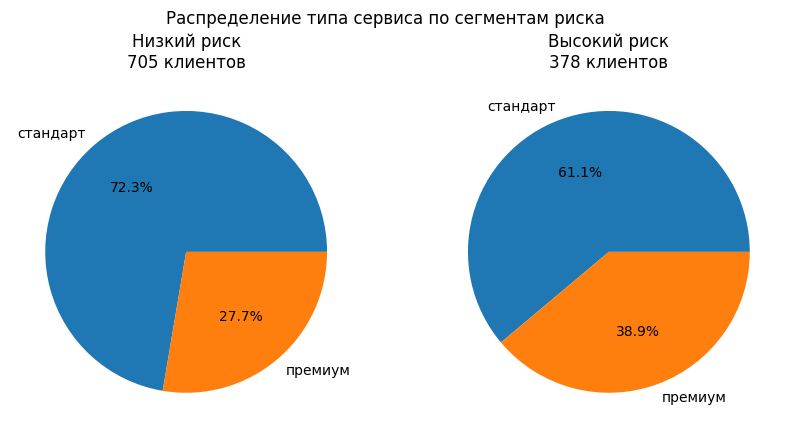

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

count_low_service = low_risk["тип_сервиса"].value_counts()
axis[0].pie(
    count_low_service.values, labels=count_low_service.index, autopct="%1.1f%%"
)
axis[0].set_title(f"Низкий риск\n{len(low_risk)} клиентов")

count_hight_service = hight_risk["тип_сервиса"].value_counts()
axis[1].pie(
    count_hight_service.values,
    labels=count_hight_service.index,
    autopct="%1.1f%%",
)
axis[1].set_title(f"Высокий риск\n{len(hight_risk)} клиентов")

plt.suptitle("Распределение типа сервиса по сегментам риска")
plt.show()

В сегменте «Высокий риск» доля клиентов с подпиской Премиум выше. Это может указывать на то, что текущие условия премиум-подписки не удерживают клиентов от снижения активности. Необходимо пересмотреть преимущества премиум-пакета или добавить дополнительные стимулы для сохранения активности.

### покупательская_активность


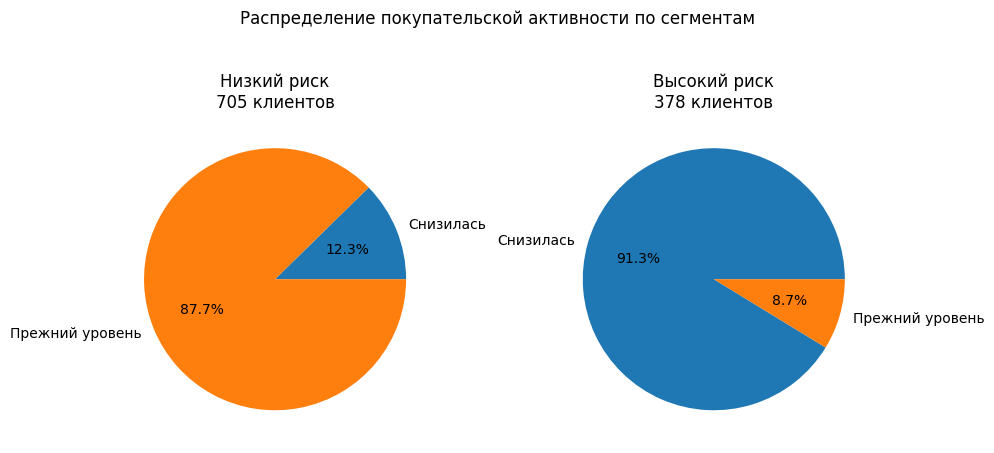

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

# Порядок категорий на графике
categories = ["Снизилась", "Прежний уровень"]

# Низкий риск
count_low = (
    low_risk["покупательская_активность"].value_counts().reindex(categories)
)
axis[0].pie(count_low.values, labels=count_low.index, autopct="%1.1f%%")
axis[0].set_title(f"Низкий риск\n{len(low_risk)} клиентов")

# Высокий риск
count_hight = (
    hight_risk["покупательская_активность"].value_counts().reindex(categories)
)
axis[1].pie(count_hight.values, labels=count_hight.index, autopct="%1.1f%%")
axis[1].set_title(f"Высокий риск\n{len(hight_risk)} клиентов")

plt.suptitle("Распределение покупательской активности по сегментам")
plt.tight_layout()
plt.show()

В сегменте «Высокий риск» 91.3% клиентов уже имеют статус «Снизилась», тогда как в сегменте «Низкий риск» таких клиентов только 12.3%. Это подтверждает, что модель прогнозирует снижение активности именно для тех клиентов, у которых оно уже произошло. Следовательно, клиенты, однажды снизившие активность, с высокой вероятностью сохранят её на низком уровне и в следующем периоде, если не принять меры.

### акционные_покупки


Низкий риск - Среднее: 0.24, Медиана: 0.21
Высокий риск - Среднее: 0.46, Медиана: 0.32


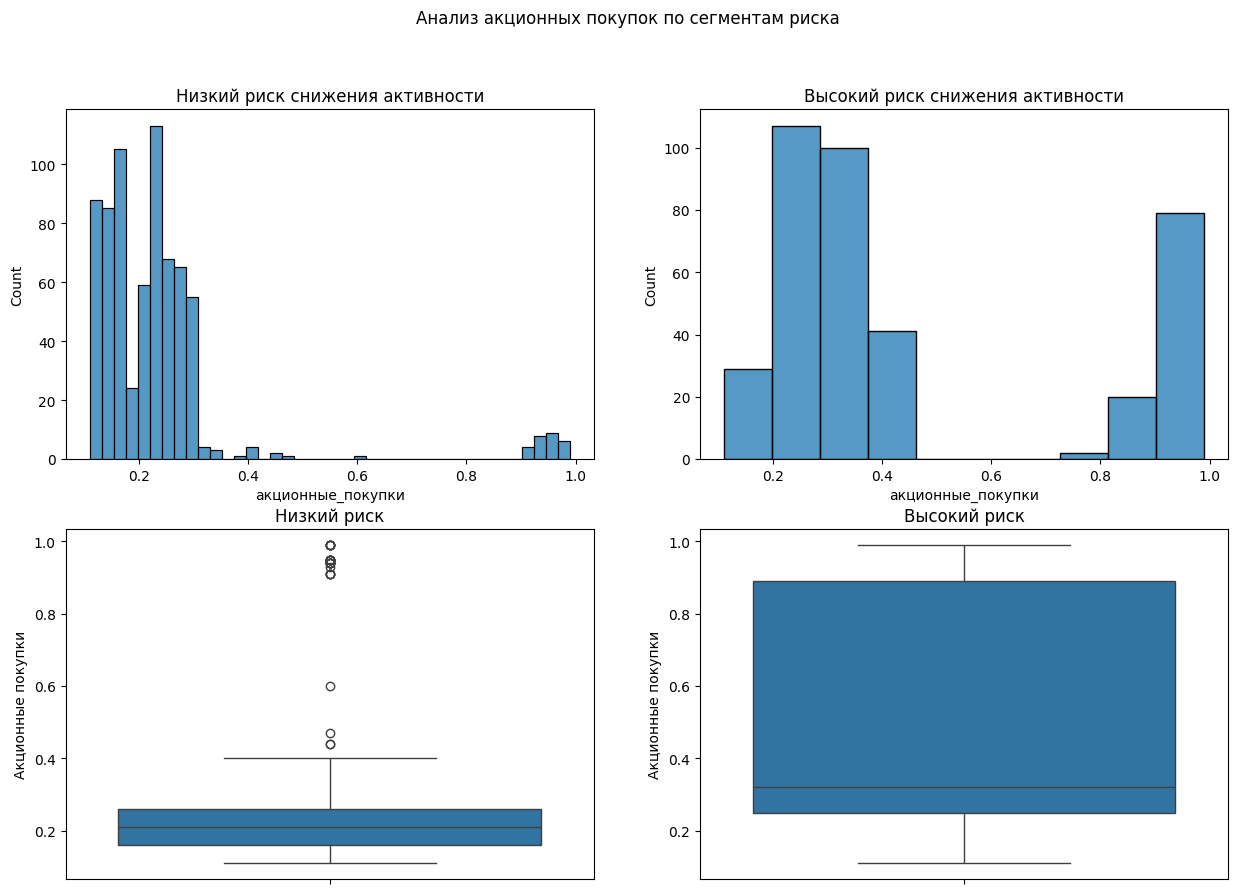

In [ ]:
print(
    f"Низкий риск - Среднее: {low_risk['акционные_покупки'].mean():.2f}, "
    f"Медиана: {low_risk['акционные_покупки'].median():.2f}"
)

print(
    f"Высокий риск - Среднее: {hight_risk['акционные_покупки'].mean():.2f}, "
    f"Медиана: {hight_risk['акционные_покупки'].median():.2f}"
)

fig, axis = plt.subplots(2, 2, figsize=(15, 10))

# Верхний ряд - гистограммы
sns.histplot(low_risk, x="акционные_покупки", ax=axis[0, 0])
axis[0, 0].set_title("Низкий риск снижения активности")

sns.histplot(hight_risk, x="акционные_покупки", ax=axis[0, 1])
axis[0, 1].set_title("Высокий риск снижения активности")

# Нижний ряд - ящики с усами
sns.boxplot(y=low_risk["акционные_покупки"], ax=axis[1, 0])
axis[1, 0].set_title("Низкий риск")
axis[1, 0].set_ylabel("Акционные покупки")

sns.boxplot(y=hight_risk["акционные_покупки"], ax=axis[1, 1])
axis[1, 1].set_title("Высокий риск")
axis[1, 1].set_ylabel("Акционные покупки")

plt.suptitle("Анализ акционных покупок по сегментам риска")
plt.show()

Клиенты с высоким риском склонны чаще совершать покупки по акции или со скидкой. Это говорит о том, что такие клиенты покупают продукцию в основном тогда, когда есть скидка или другая возможность сэкономить. Это может означать, что после крупной покупки по акции клиент снижает активность, ожидая новых предложений. Рекомендуется персонализированно предлагать таким клиентам скидки для удержания активности.

### разрешить_сообщать


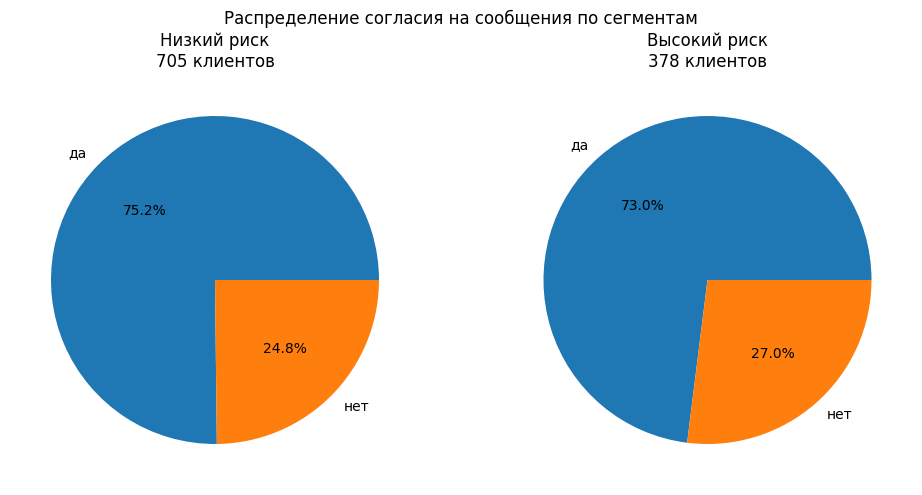

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

# Порядок категорий на графике
categories = ["да", "нет"]

# Низкий риск
count_low = low_risk["разрешить_сообщать"].value_counts().reindex(categories)
axis[0].pie(count_low.values, labels=count_low.index, autopct="%1.1f%%")
axis[0].set_title(f"Низкий риск\n{len(low_risk)} клиентов")

# Высокий риск
count_hight = (
    hight_risk["разрешить_сообщать"].value_counts().reindex(categories)
)
axis[1].pie(count_hight.values, labels=count_hight.index, autopct="%1.1f%%")
axis[1].set_title(f"Высокий риск\n{len(hight_risk)} клиентов")

plt.suptitle("Распределение согласия на сообщения по сегментам")
plt.tight_layout()
plt.show()

Разница между сегментами минимальна (около 2%). Это позволяет предположить, что согласие на получение сообщений не является значимым фактором, влияющим на покупательскую активность. Клиенты из группы высокого риска не отказываются от коммуникации, но это не помогает им сохранять активность. Персонализированные предложения для удержания клиентов из группы высокого риска можно отправлять без ограничений — большинство (73%) дали согласие на коммуникацию.

### маркет*актив_6*мес


Низкий риск - Среднее: 4.54, Медиана: 4.40
Высокий риск - Среднее: 3.53, Медиана: 3.55


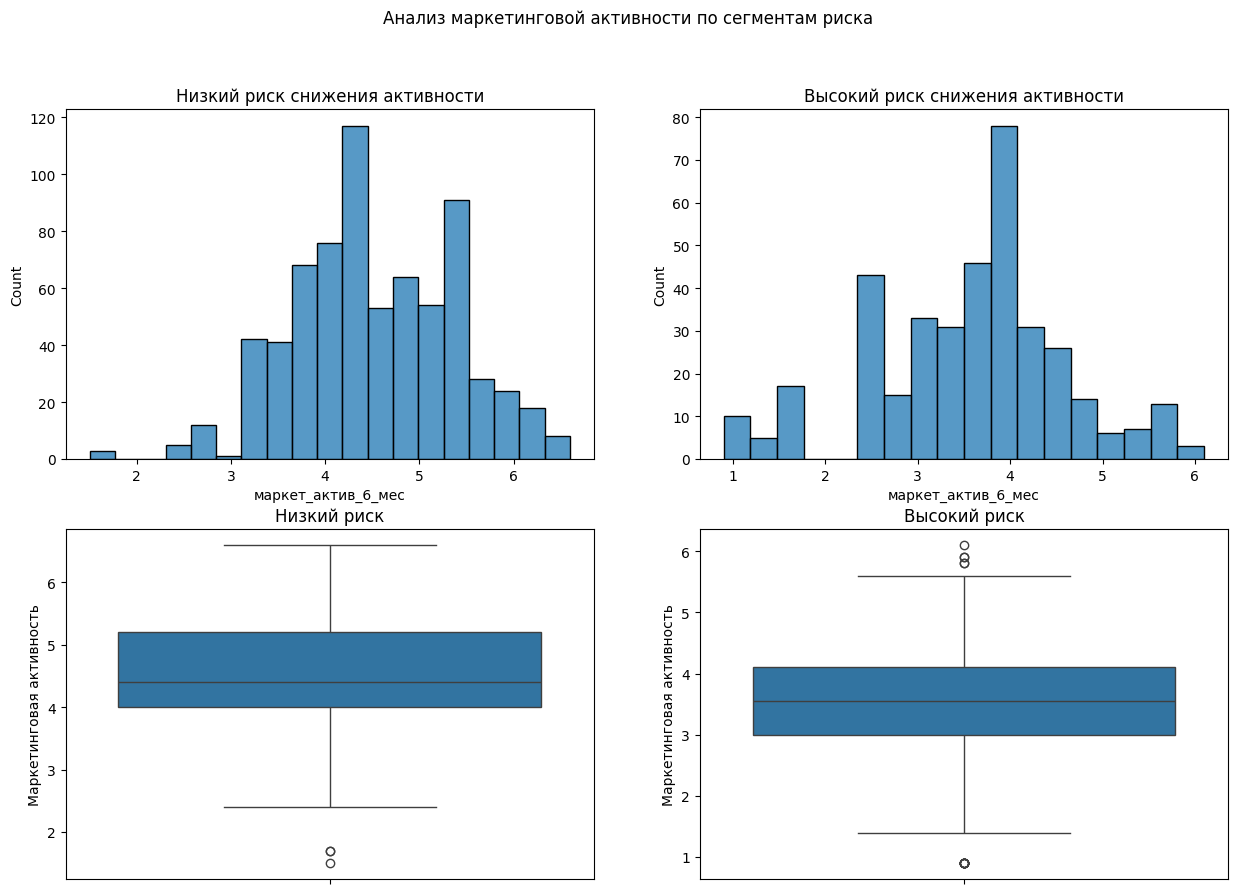

In [ ]:
print(
    f"Низкий риск - Среднее: {low_risk['маркет_актив_6_мес'].mean():.2f}, "
    f"Медиана: {low_risk['маркет_актив_6_мес'].median():.2f}"
)
print(
    f"Высокий риск - Среднее: {hight_risk['маркет_актив_6_мес'].mean():.2f}, "
    f"Медиана: {hight_risk['маркет_актив_6_мес'].median():.2f}"
)

fig, axis = plt.subplots(2, 2, figsize=(15, 10))

# Верхний ряд - гистограммы
sns.histplot(low_risk, x="маркет_актив_6_мес", ax=axis[0, 0])
axis[0, 0].set_title("Низкий риск снижения активности")

sns.histplot(hight_risk, x="маркет_актив_6_мес", ax=axis[0, 1])
axis[0, 1].set_title("Высокий риск снижения активности")

# Нижний ряд - ящики с усами
sns.boxplot(y=low_risk["маркет_актив_6_мес"], ax=axis[1, 0])
axis[1, 0].set_title("Низкий риск")
axis[1, 0].set_ylabel("Маркетинговая активность")

sns.boxplot(y=hight_risk["маркет_актив_6_мес"], ax=axis[1, 1])
axis[1, 1].set_title("Высокий риск")
axis[1, 1].set_ylabel("Маркетинговая активность")

plt.suptitle("Анализ маркетинговой активности по сегментам риска")
plt.show()

Сегмент «Низкий риск» получал в среднем на 1 маркетинговое взаимодействие больше, чем сегмент «Высокий риск» (4.54 против 3.53). Это может свидетельствовать о том, что недостаток коммуникации с клиентом способствует снижению его покупательской активности.

Количество клиентов, которые дали согласие на отправку уведомлений, одинаковое для двух сегментов (75% и 73%). Значит, версия о том, что маркетологи стали реже писать из-за отказа от рекламы, не работает.

### ошибка_сервиса


Низкий риск - Среднее: 4.38, Медиана: 4.00
Высокий риск - Среднее: 3.77, Медиана: 3.00


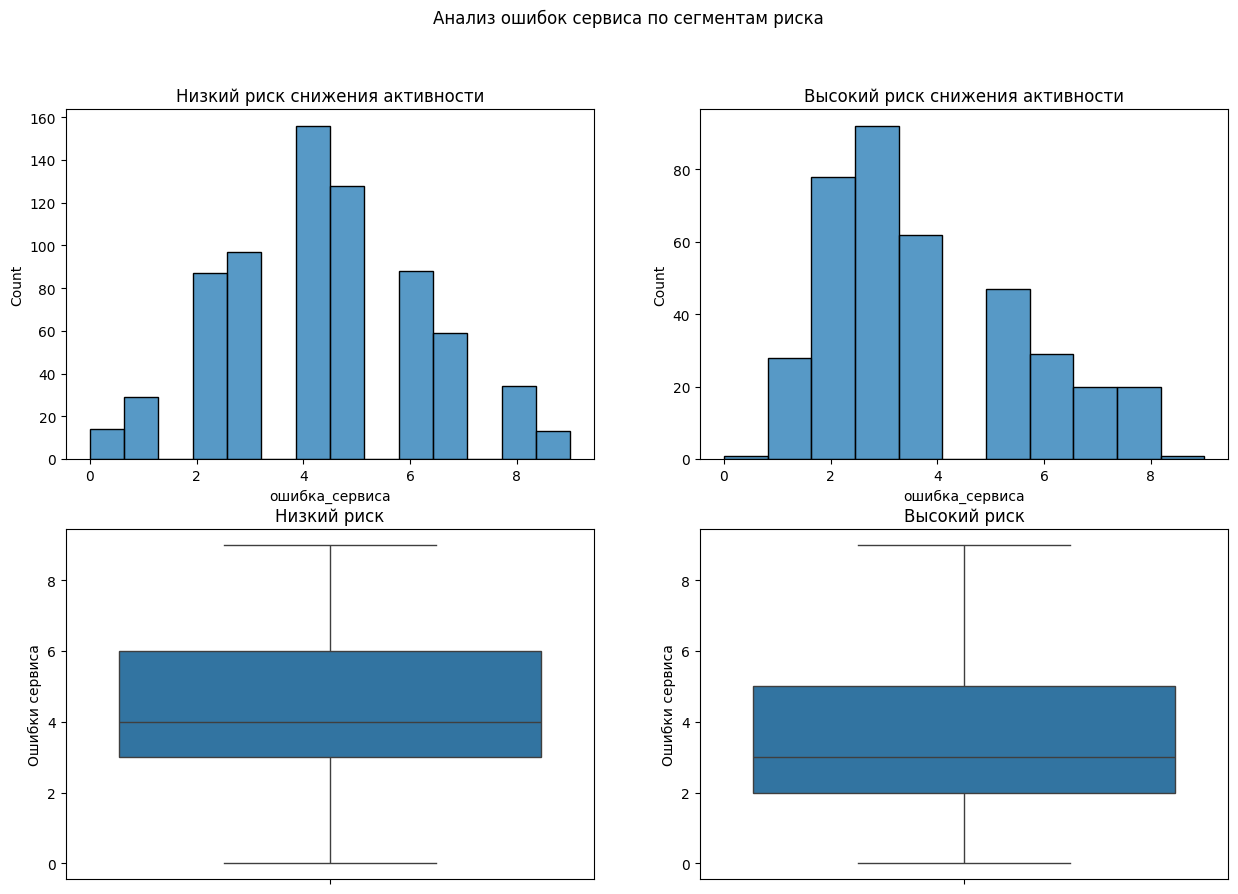

In [ ]:
print(
    f"Низкий риск - Среднее: {low_risk['ошибка_сервиса'].mean():.2f}, "
    f"Медиана: {low_risk['ошибка_сервиса'].median():.2f}"
)
print(
    f"Высокий риск - Среднее: {hight_risk['ошибка_сервиса'].mean():.2f}, "
    f"Медиана: {hight_risk['ошибка_сервиса'].median():.2f}"
)

fig, axis = plt.subplots(2, 2, figsize=(15, 10))

# Верхний ряд - гистограммы
sns.histplot(low_risk, x="ошибка_сервиса", ax=axis[0, 0])
axis[0, 0].set_title("Низкий риск снижения активности")

sns.histplot(hight_risk, x="ошибка_сервиса", ax=axis[0, 1])
axis[0, 1].set_title("Высокий риск снижения активности")

# Нижний ряд - ящики с усами
sns.boxplot(y=low_risk["ошибка_сервиса"], ax=axis[1, 0])
axis[1, 0].set_title("Низкий риск")
axis[1, 0].set_ylabel("Ошибки сервиса")

sns.boxplot(y=hight_risk["ошибка_сервиса"], ax=axis[1, 1])
axis[1, 1].set_title("Высокий риск")
axis[1, 1].set_ylabel("Ошибки сервиса")

plt.suptitle("Анализ ошибок сервиса по сегментам риска")
plt.show()

Количество ошибок сервиса в сегменте «Высокий риск» ниже (3.77 против 4.38), но и время на сайте у этих клиентов значительно меньше. Вероятно, снижение активности связано не с техническими проблемами.

### Вывод о выбраном сегмента

Для дополнительного исследования выбран сегмент «Высокий риск снижения покупательской активности», включающий 378 клиентов (около 30% от общей базы). Выбор пал на него, потому что данный сегмент демонстрирует наибольшую выручку (медиана 5316.50 руб.), но при этом 91.3% клиентов уже имеют статус «Снизилась». Без своевременных мер эти клиенты с высокой вероятностью сохранят низкую активность в следующем периоде.

Анализ показал, что клиенты из сегмента «Высокий риск» имеют высокую выручку, но при этом проводят на сайте значительно меньше времени (10 минут против 16 минут в сегменте «Низкий риск»). Среди них преобладают премиум-клиенты, что говорит о неэффективности текущих условий подписки для удержания активности. Такие клиенты склонны чаще совершать покупки по акции, что может указывать на крупные покупки: сделав затраты по скидке, клиент снижает активность, ожидая новых предложений. Маркетинговая активность в этом сегменте ниже на одно взаимодействие, при этом доля согласившихся на коммуникацию практически не отличается от сегмента «Низкий риск» (73% против 75%). Ошибки сервиса не влияют на снижение активности.

На основе проведённого анализа предлагаются следующие меры для сегмента «Высокий риск».

Во-первых, необходимо увеличить частоту маркетинговых коммуникаций до уровня сегмента «Низкий риск», так как недостаток взаимодействия может способствовать снижению активности, а большинство клиентов (73%) дали согласие на получение сообщений.

Во-вторых, следует предлагать персонализированные скидки. Клиенты этого сегмента чувствительны к акциям, и своевременное предложение скидки после крупной покупки может удержать их от полного ухода.

В-третьих, требуется пересмотреть преимущества премиум-подписки. Дополнительные стимулы или бонусы для этой категории помогут сохранить активность.

В-четвёртых, необходимо повышать вовлеченность клиентов через контент или специальные предложения, так как текущее время на сайте в этом сегменте ниже.

## Вывод

Интернет-магазин «Победа качества» столкнулся со снижением покупательской активности постоянных клиентов. Привлечение новых клиентов неэффективно, так как целевая аудитория уже знает о магазине. Руководство приняло решение удерживать активность существующих клиентов с помощью персонализированных предложений на основе анализа данных и бизнес-моделирования.

Моя задача как аналитика заключалась в разработке решения для персонализации предложений постоянным клиентам с целью увеличения их покупательской активности.

Для этого было необходимо:

- провести описательный анализ данных из пяти таблиц;
- отобрать клиентов с активностью не менее трёх месяцев;
- объединить таблицы в одну;
- провести корреляционный анализ количественных признаков;
- на основе результатов моделирования и данных о прибыльности выполнить сегментацию покупателей;
- выделить сегмент для дополнительного исследования и предложить меры по увеличению его покупательской активности.

### Описание исходных данных и проведённая предобработка

Исходные данные представлены пятью таблицами:

market_file.csv — данные о поведении покупателей на сайте, коммуникациях и продуктовых предпочтениях

market_money.csv — данные о выручке по периодам (текущий, предыдущий, препредыдущий месяц).

market_time.csv — данные о времени, проведённом на сайте по периодам.

money.csv — данные о среднемесячной прибыли от каждого клиента за последние 3 месяца.

forecast_chan.csv — результаты моделирования: вероятность снижения покупательской активности для каждого клиента.

Предобработка данных включала следующие шаги:

- Исправление кодировки — текстовые столбцы были приведены к читаемому виду с помощью функции fix_text().
- Приведение названий столбцов — все названия переведены в нижний регистр, пробелы заменены на подчёркивания.
- Обработка пропусков — пропуски в числовых столбцах заполнены медианными значениями.
- Удаление дубликатов — дубликатов не было.
- Работа с выбросами — в числовых столбцах выбросы не удалялись, но были проанализированы отдельно. Аномальное значение выручки в market_money.csv признано случайной ошибкой.
- Приведение типов данных — категориальные приведены к типу category.
- Отбор активных клиентов — оставлены только клиенты с покупательской активностью не менее трёх месяцев (покупки во всех трёх периодах).
- Объединение таблиц — таблицы market_file.csv, market_money.csv и market_time.csv объединены в одну (merge_market_df) с созданием отдельных столбцов для выручки и времени по каждому периоду.

### Выводы и дополнительные предложения для выбранного сегмента покупателей.

Выбранный сегмент: «Высокий риск снижения покупательской активности» (378 клиентов, 32.5% от всех активных).

Их медиана выручки выше (5316.50 руб.), чем в сегменте низкого риска (5111.50 руб.), но 91.3% из них уже имеют статус «Снизилась». Это говорит о том, что снижение активности — устойчивое состояние, и без мер клиенты не восстановятся.

Клиенты из сегмента высокого риска проводят на сайте значительно меньше времени — медиана 10 минут против 16 минут в сегменте низкого риска. Это указывает на низкую вовлеченность.

В сегменте высокого риска преобладают премиум-клиенты. Текущие условия премиум-подписки не удерживают их от снижения активности.

Клиенты с высоким риском склонны чаще совершать покупки по акции. Средняя доля акционных покупок у них выше, чем у клиентов с низким риском. Это говорит о высокой чувствительности к скидкам.

Маркетинговая активность в сегменте высокого риска ниже (3.53 против 4.54). При этом 73% клиентов дали согласие на получение сообщений, что позволяет коммуницировать с ними без ограничений.

Количество ошибок сервиса в сегменте высокого риска ниже, но и время на сайте у этих клиентов значительно меньше, поэтому ошибки не являются ключевым фактором снижения активности.

### Предложения по увеличению покупательской активности

- Увеличить частоту маркетинговых коммуникаций до уровня сегмента низкого риска. 73% клиентов согласны на получение сообщений.
- Предлагать персонализированные скидки — клиенты чувствительны к акциям, это может удержать их после крупных покупок.
- Пересмотреть преимущества премиум-подписки — текущие условия не удерживают премиум-клиентов.
- Повысить вовлечённость на сайте — клиенты проводят мало времени.
